<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install gensim

In [3]:
# importing all the essential dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk # to preprocess text data
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import pickle # to save the tokenizer model
nltk.download('punkt_tab')
nltk.download('stopwords')
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM, LayerNormalization, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.head()

,title,text,rating
0,BEST protection for many equipment needs!,I purchased the SKB mid-sized hardware case af...,5
1,Good value,"Well made, good fit & finish, does the job! I...",5
2,Nice for gaming,Sound quality is very good for gaming and onli...,5
3,Easy to use and good power,Unit is easy to set up and puts out great soun...,5
4,Sturdy stands,I purchased two of these to hang shotgun mics ...,5


In [5]:
df.shape

(50000, 3)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   49994 non-null  object
 1   text    49995 non-null  object
 2   rating  50000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [7]:
print(df.isnull().sum())
df.dropna(inplace=True)
df.shape

title     6
text      5
rating    0
dtype: int64


(49989, 3)

- The objective is to build a binary classifier. Since reviews with a rating of 3 often express mixed sentiment, it is preferable to remove them.

In [8]:
df = df[df['rating'] != 3]

- The function below transforms the reviews into two sentiment categories: positive and negative. Reviews with ratings of 1 or 2 are labeled as negative, while all other ratings are labeled as positive.

In [9]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 'Negative'
  else:
    return "Positive"

df['sentiment'] = df['rating'].apply(get_sentiment)

In [10]:
stop_words = stopwords.words('english')

# function to clean the reviews
def clean_txt(text):
  text = text.lower()
  cleaned_text = re.sub(r'[^a-z0-9\s]', '', text)
  tokens = word_tokenize(cleaned_text)
  filtered_text = [word for word in tokens if word not in stop_words]
  filtered_text = ' '.join(filtered_text)
  return filtered_text

df['preprocessed_text'] = df['text'].apply(lambda x: clean_txt(x))

In [11]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,39684
Negative,6874


- We have a significantly imbalanced dataset.

In [12]:
X = df['preprocessed_text']
y = df['sentiment']

y = y.map({'Negative': 0, 'Positive': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(37246,) (37246,)
(9312,) (9312,)


In [13]:
VOCAB_SIZE = 20000 # unique words
MAXLEN = 150 # length of the sequence
VECTOR_SIZE = 100 # the number of dimensions for each word

- The tokenizer creates tokens by assigning a unique integer to each word. It is fit on the training data and then generates sequences for both the training and test sets.

In [14]:
tokenizer = Tokenizer(20000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

- 'word_index' attribute in tokenizer will give us a dictionary that contains the words and its corresponding tokens which we can use later to create the embedding matrix. I stored it in a variable called word_index.

In [15]:
word_index= tokenizer.word_index

- `pad_sequences` creates sequences for each review. I set the maximum length of each review to 150, with both padded and truncating set to 'pre'. Any review longer than 150 will be truncated from the beginning, and any review shorter than 150 will be padded with 0s at the beginning.

In [16]:
X_train_padded = pad_sequences(X_train_sequences, maxlen= MAXLEN, dtype='float32', padding='pre', truncating='pre')
X_test_padded = pad_sequences(X_test_sequences, maxlen= MAXLEN, dtype='float32', padding='pre', truncating='pre')

In [17]:
txt_seqs = [text.split() for text in X_train]

In [18]:
# word2vec model
word2vec = Word2Vec(txt_seqs,
                    window=5,
                    vector_size=VECTOR_SIZE,
                    min_count=2,
                    sg=0)

In [19]:
embeddings_matrix = np.zeros((VOCAB_SIZE, VECTOR_SIZE))  # (no of rows, no of columns) of zeros

for word, i in word_index.items():
  if i >= VOCAB_SIZE:
    continue
  if word in word2vec.wv:
    embeddings_matrix[i] = word2vec.wv[word]

In [21]:
model_path = "/content/drive/MyDrive/Sentiment-Classification/lstm.keras"
tokenizer_path = '/content/drive/MyDrive/Sentiment-Classification/'

In [22]:
# saving the tokenizer
with open(tokenizer_path + 'tokenizer.pickle', 'wb') as t:
  pickle.dump(tokenizer, t)

In [23]:
# model
model = Sequential()
model.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=VECTOR_SIZE,
                     weights = [embeddings_matrix],
                    input_shape = (MAXLEN,),
                     trainable = False
                     ))

model.add(SpatialDropout1D(0.3))

model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(LayerNormalization())
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(LayerNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_s = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, mode='min')

checkpoint = ModelCheckpoint(filepath = model_path,
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,088,961 (7.97 MB)

 Trainable params: 88,961 (347.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [24]:
# training the model
history = model.fit(X_train_padded,
                    y_train,
                    validation_split=0.2,
                    batch_size=64,
                    epochs = 20,
                    callbacks=[early_s, checkpoint])

Epoch 1/20
465/466 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8431 - loss: 0.3757
Epoch 1: val_accuracy improved from None to 0.89477, saving model to /content/drive/MyDrive/Sentiment-Classification/lstm.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Sentiment-Classification/lstm.keras
466/466 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8648 - loss: 0.3239 - val_accuracy: 0.8948 - val_loss: 0.2475
Epoch 2/20
464/466 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8905 - loss: 0.2687
Epoch 2: val_accuracy improved from 0.89477 to 0.90268, saving model to /content/drive/MyDrive/Sentiment-Classification/lstm.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Sentiment-Classification/lstm.keras
466/466 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.8887 - loss: 0.2685 - val_accuracy: 0.9027 - val_loss: 0.2336
Epoch 3/20
464/466 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8929 - loss: 0.2602
Epoch 3: val_accuracy improved from 0.90268 to 0.90376

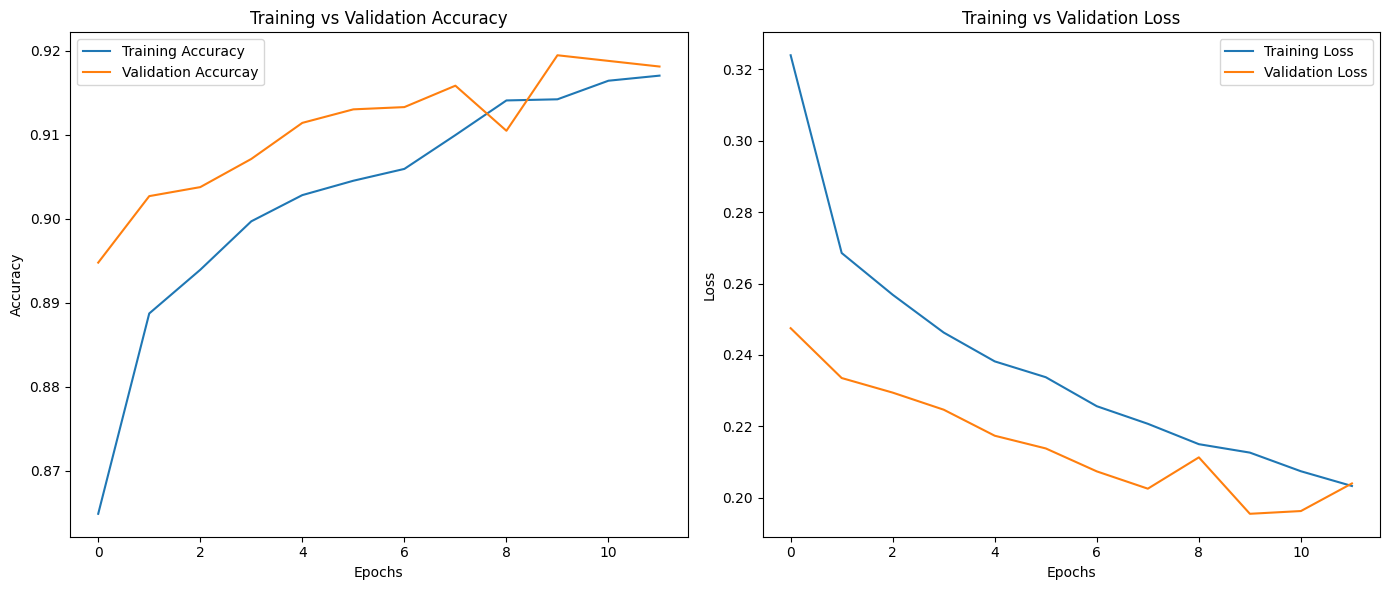

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))

sns.lineplot(history.history['accuracy'], ax = axs[0], label="Training Accuracy")
sns.lineplot(history.history['val_accuracy'], ax= axs[0], label="Validation Accurcay")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].set_title("Training vs Validation Accuracy")

sns.lineplot(history.history['loss'], ax = axs[1], label="Training Loss")
sns.lineplot(history.history['val_loss'], ax = axs[1], label="Validation Loss")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].set_title("Training vs Validation Loss")

plt.tight_layout()
plt.show()

In [26]:
acc, loss = model.evaluate(X_test_padded, y_test)
print("Accuracy on the test data: ", acc)
print("Loss on the test data: ", loss)

291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9166 - loss: 0.2062
Accuracy on the test data:  0.2061629593372345
Loss on the test data:  0.9165592789649963


- The LSTM model achieved 91% accuracy on the test data.

In [27]:
y_preds = model.predict(X_test_padded)

291/291 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [28]:
predictions = []
for pred in y_preds:
  if pred >= 0.5:
    predictions.append(1)
  else:
    predictions.append(0)

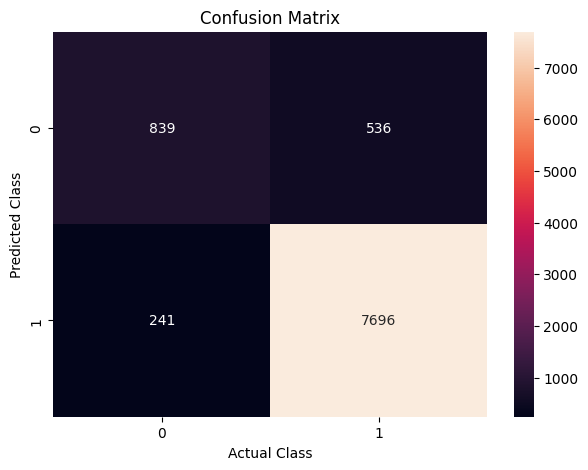

In [30]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='.0f')
plt.title("Confusion Matrix")
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.show()

In [31]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.61      0.68      1375
           1       0.93      0.97      0.95      7937

    accuracy                           0.92      9312
   macro avg       0.86      0.79      0.82      9312
weighted avg       0.91      0.92      0.91      9312



In [32]:
# function to predict new reviews
def predict_sentiment(review):
  text = clean_txt(review)
  seq = tokenizer.texts_to_sequences([text])
  padded = pad_sequences(seq, maxlen= MAXLEN, dtype='float32', padding='pre', truncating='pre')
  pred = model.predict(padded)

  if pred >= 0.5:
    return "Positive"
  else:
    return "Negative"

In [33]:
text1 = "I like how portable this stand and that it gas page holders"
text2 = "Does not work with my android phone! Complete waste"

In [34]:
predict_sentiment(text1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


'Positive'

In [35]:
predict_sentiment(text2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


'Negative'